In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"  # KMeans memory leak

In [2]:
import FloodAnalyzer
import importlib
import utils.analogue_utils as analogue_utils
import numpy as np

from utils import flood_data_loader

In [3]:
def reload():
    importlib.reload(FloodAnalyzer)
    importlib.reload(analogue_utils)

# Data

In [4]:
flagged_months: list
flagged_months = flood_data_loader.load_flood_months()  # type: ignore

reported_flood_months = ["2008-09", "2016-04", "2018-04", "2018-09",
                         "2021-11", "2023-09", "2024-10"]

dcfi_da, dcfi_components = analogue_utils.calculate_dcfi("2024-12-31")

In [5]:
dcfi_df = analogue_utils.calculate_daily_water_level(da=dcfi_da,
                                                     temporal_agg="max",
                                                     spatial_agg="mean")

In [6]:
dcfi_p95 = np.quantile(dcfi_df["water_level"], 0.95).round(2)
print(f"Water Level 95th percentile: {dcfi_p95}")
dcfi_df["water_level"].describe().round(2)

Water Level 95th percentile: 1.36


count    11808.00
mean         1.20
std          0.10
min          0.89
25%          1.13
50%          1.19
75%          1.26
max          1.68
Name: water_level, dtype: float64

# Analysis

In [17]:
importlib.reload(FloodAnalyzer)

<module 'FloodAnalyzer' from 'c:\\Users\\steve\\OneDrive\\Documents\\PhD\\Forecasting_pub\\FloodAnalyzer.py'>

In [18]:
configs: list[FloodAnalyzer.ClusteringConfig] = [
    {'method': 'kmeans', 'n_clusters': 6},
]

clustered = FloodAnalyzer.ClusterFloodSignals(data=dcfi_df)
clustered.run(configs)
analyzer = FloodAnalyzer.ResultAnalyzer(clustered)

In [19]:
active_config = "kmeans_k6"
analyzer.active_config = active_config
analyzer.config_cluster_stats

,Cluster,mean,min,max,std,size,is_extreme,rank,size_pct
0,0,1.12,1.08,1.15,0.02,2460,False,5,20.83
1,1,1.31,1.28,1.36,0.02,1781,False,2,15.08
2,2,1.18,1.15,1.21,0.02,2916,False,4,24.70
3,3,1.05,0.89,1.08,0.03,1349,False,6,11.42
4,4,1.40,1.36,1.68,0.04,692,True,1,5.86
5,5,1.24,1.21,1.28,0.02,2610,False,3,22.10


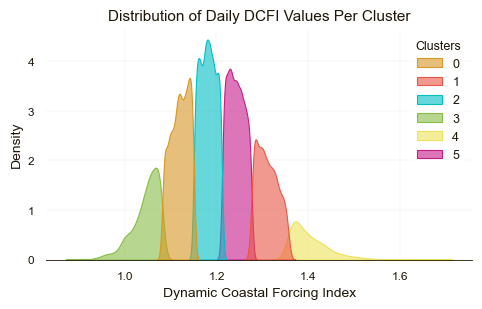

In [20]:
analyzer.plot_kde()


In [12]:
extreme_days = analyzer.extreme_days(selected_months=flagged_months,full_month_str=True)
print(extreme_days["n_days"].sum())
extreme_days

118.0


,month_str,days,n_days,gpd_major_days,gpd_moderate_days,gpd_minor_days
119,August 2002,,NaN,,,
132,September 2003,,NaN,,,
142,July 2004,9,1.0,,,
154,July 2005,"22, 23",2.0,,22,
168,September 2006,"8, 9, 10, 21, 25",5.0,10,,"21, 25"
178,July 2007,"1, 29, 30",3.0,29,,
191,August 2008,"22, 29, 30, 31",4.0,,29,
192,September 2008,"4, 5",2.0,4,,
204,September 2009,"17, 18, 19, 20, 21",5.0,20,,
212,May 2010,"13, 14",2.0,,,14


# Statistical Testing

In [21]:
from sklearn.cluster import KMeans

In [22]:
X = dcfi_df["water_level"].to_numpy().reshape(-1,1)

extreme_sets = []
for seed in range(50):
    km = KMeans(n_clusters=6, random_state=seed, n_init=50, tol=0.0001).fit(X)
    labels = km.labels_
    extreme_cluster = np.argmax([X[labels == i][:,0].mean() for i in np.unique(labels)])
    extreme_sets.append(set(np.where(labels == extreme_cluster)[0]))

# Compute overlap of extreme cluster membership across runs
base = extreme_sets[0]
stabilities = [len(base & s) / len(base | s) for s in extreme_sets[1:]]
print("Mean stability:", np.mean(stabilities))


Mean stability: 0.9651675131672249


In [23]:
results = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42,  n_init=50, tol=0.0001).fit(X)
    labels = km.labels_
    extreme_cluster = np.argmax([X[labels == i][:,0].mean() for i in np.unique(labels)])
    results[k] = set(np.where(labels == extreme_cluster)[0])

# Compare overlap between k=6 baseline and other k values
base = results[6]
overlap = {k: len(base & results[k]) / len(base | results[k]) for k in results if k != 6}
print(overlap)


{3: 0.25497420781134855, 4: 0.42558425584255843, 5: 0.6947791164658634, 7: 0.6026011560693642, 8: 0.5505780346820809}
